# 🛍️ Product / Retail Recommendation System
## Notebook 1: Data Preparation & Exploratory Data Analysis

**Intern:** Sabin Lamsal <br>
**Company:** Miss Misoo Production <br>
**Dataset:** Retailrocket Recommender Dataset <br>
**Date:** March 2026 <br>

---

### What This Notebook Covers
This notebook takes raw Retailrocket clickstream data and transforms it into clean, analysis-ready datasets:

  - **Data Understanding:**  exploring what we're working with

  - **Data Cleaning:** handling timestamps, duplicates, missing values

  - **Feature Engineering:**  creating sessions, interaction weights, user-item matrices

  - **Exploratory Analysis:** understanding user behavior, product popularity, patterns

  - **Saving Results:** preparing data for the modeling notebook



##  Setup and Environment

In [1]:
#Install necessary packages
!pip install -q pandas numpy matplotlib seaborn plotly tqdm

In [8]:
# Clone the repository
!git clone https://github.com/sabin74/Retailrocket-Recommender-System.git
!git lfs pull

Cloning into 'Retailrocket-Recommender-System'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), done.


In [9]:
#  Set up paths and imports
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import defaultdict
from itertools import combinations
from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [10]:
# Set working directory
os.chdir("/content/Retailrocket-Recommender-System")
print("Current Directory:", os.getcwd())


Current Directory: /content/Retailrocket-Recommender-System


In [11]:
# Create folder structure
PROJECT_PATH = "."
DATA_PATH = os.path.join(PROJECT_PATH, "data", "raw")
ARTIFACT_PATH = os.path.join(PROJECT_PATH, "data", "processed")
OUTPUT_PATH = os.path.join(PROJECT_PATH, "output", "figures")

# Create directories if they don't exist
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(ARTIFACT_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(PROJECT_PATH, "output", "evaluation_results"), exist_ok=True)

## Understanding the Dataset
### About the Data
This is real clickstream data from an e-commerce website, collected over 4.5 months. All user and product IDs are anonymized for privacy.


### Files we're working with:

 - **events.csv:** user interactions (views, cart adds, purchases)

 - **item_properties.csv:** product attributes (in two parts)

 - **category_tree.csv:** product category hierarchy


 ### Event Types:

 - **view:** user looked at a product (weak signal)

 - **addtocart:** user added to cart (medium signal)

 - **transaction:** user bought product (strong signal)

In [12]:

# Load the data

# Load events (specify dtypes to save memory)
events = pd.read_csv(
    os.path.join(DATA_PATH, 'events.csv'),
    dtype={
        'visitorid': 'int32',
        'itemid': 'int32',
        'transactionid': 'float32'
    }
)

# Load item properties (they come in two parts)
item_props1 = pd.read_csv(os.path.join(DATA_PATH, 'item_properties_part1.csv'))
item_props2 = pd.read_csv(os.path.join(DATA_PATH, 'item_properties_part2.csv'))
item_props = pd.concat([item_props1, item_props2], ignore_index=True)

# Free up memory
del item_props1, item_props2

# Load category tree
category_tree = pd.read_csv(os.path.join(DATA_PATH, 'category_tree.csv'))



In [13]:

#  Quick look at the data

print(f"\nEvents dataset: {events.shape[0]:,} rows, {events.shape[1]} columns")
print(f"Item properties: {item_props.shape[0]:,} rows, {item_props.shape[1]} columns")
print(f"Category tree: {category_tree.shape[0]:,} rows, {category_tree.shape[1]} columns")

print("\nFirst few rows of events:")
display(events.head())

print("\nEvent types breakdown:")
event_counts = events['event'].value_counts()
for event_type, count in event_counts.items():
    percentage = (count/len(events))*100
    print(f"   {event_type:<12}: {count:>8,} ({percentage:.1f}%)")


Events dataset: 2,756,101 rows, 5 columns
Item properties: 20,275,902 rows, 4 columns
Category tree: 1,669 rows, 2 columns

First few rows of events:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN



Event types breakdown:
   view        : 2,664,312 (96.7%)
   addtocart   :   69,332 (2.5%)
   transaction :   22,457 (0.8%)


## Data Cleaning and Preprocessing

In [14]:
# Check for missing values
missing = events.isnull().sum()

print(missing[missing > 0] if any(missing > 0) else "No missing values found!")
print("\n(Note: transactionid is empty for non-purchase events - this is normal)")


transactionid    2733644
dtype: int64

(Note: transactionid is empty for non-purchase events - this is normal)


In [15]:
# Handle timestamps (Converting timestamps to datetime)

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['day'] = events['datetime'].dt.day
events['month'] = events['datetime'].dt.month
events['dayofweek'] = events['datetime'].dt.day_name()
events['week'] = events['datetime'].dt.isocalendar().week

print(f"\nDate range: {events['datetime'].min()} to {events['datetime'].max()}")
print(f"Total days: {(events['datetime'].max() - events['datetime'].min()).days} days")



Date range: 2015-05-03 03:00:04.384000 to 2015-09-18 02:59:47.788000
Total days: 137 days


In [16]:
# Remove duplicate records
before = len(events)
events = events.drop_duplicates(subset=['visitorid', 'itemid', 'event', 'timestamp'])
after = len(events)

print(f"   Before: {before:,} rows")
print(f"   After:  {after:,} rows")
print(f"   Removed: {before-after:,} duplicates")

   Before: 2,756,101 rows
   After:  2,755,641 rows
   Removed: 460 duplicates


In [17]:
# Create interaction weights
# Different events have different importance

weight_map = {
    'view': 1,          # browsing - weak signal
    'addtocart': 3,     # interest - medium signal
    'transaction': 5    # purchase - strong signal
}

events['weight'] = events['event'].map(weight_map)

print("Event weights:")
for event, weight in weight_map.items():
    print(f"   {event:<12}: {weight}")

Event weights:
   view        : 1
   addtocart   : 3
   transaction : 5


## Feature Engineering

In [18]:
# Create session IDs (30-minute timeout)

# Sort data by user and time
df = events.sort_values(['visitorid', 'timestamp']).copy()

# Calculate time difference between user's events
df['time_diff'] = df.groupby('visitorid')['timestamp'].diff().fillna(0)

# New session if time difference > 30 minutes (30 * 60 * 1000 ms)
timeout = 30 * 60 * 1000
df['new_session'] = ((df['time_diff'] > timeout) |
                     (df['visitorid'] != df['visitorid'].shift(1))).astype(int)

# Create session ID
df['session_num'] = df.groupby('visitorid')['new_session'].cumsum()
df['session_id'] = df['visitorid'].astype(str) + '_' + df['session_num'].astype(str)

print(f"\nSession stats:")
print(f"  Total sessions: {df['session_id'].nunique():,}")
print(f"  Avg events per session: {len(df)/df['session_id'].nunique():.2f}")
print(f"  Avg sessions per user: {df['session_id'].nunique()/df['visitorid'].nunique():.2f}")



Session stats:
  Total sessions: 1,761,675
  Avg events per session: 1.56
  Avg sessions per user: 1.25


In [19]:
# Extract product categories

# Sort by timestamp to get latest values
item_props_sorted = item_props.sort_values('timestamp', ascending=False)

# Get category for each product
item_category = (
    item_props_sorted[item_props_sorted['property'] == 'categoryid']
    .drop_duplicates(subset='itemid', keep='first')
    [['itemid', 'value']]
    .rename(columns={'value': 'categoryid'})
)
item_category['categoryid'] = pd.to_numeric(item_category['categoryid'], errors='coerce')

# Get availability for each product
item_available = (
    item_props_sorted[item_props_sorted['property'] == 'available']
    .drop_duplicates(subset='itemid', keep='first')
    [['itemid', 'value']]
    .rename(columns={'value': 'available'})
)

# Merge category and availability
item_meta = item_category.merge(item_available, on='itemid', how='left')
item_meta['available'] = pd.to_numeric(item_meta['available'], errors='coerce').fillna(1)

print(f"\nGot metadata for {len(item_meta):,} products")
print("\nSample products:")
display(item_meta.head())

# Free memory
del item_props, item_props_sorted



Got metadata for 417,053 products

Sample products:


,itemid,categoryid,available
0,91936,1404,0
1,336721,507,1
2,266628,1085,0
3,69817,176,0
4,284730,937,0


In [20]:
# Merge metadata with events
print("\nAdding product info to events")
df = df.merge(item_meta, on='itemid', how='left')
df['categoryid'] = df['categoryid'].fillna(-1).astype('int32')
df['available'] = df['available'].fillna(1).astype('int32')

# Check coverage
known_cats = (df['categoryid'] != -1).sum()
coverage = (known_cats/len(df))*100
print(f"\nCategory coverage:")
print(f"  Events with category: {known_cats:,} ({coverage:.1f}%)")
print(f"  Events without category: {len(df)-known_cats:,} ({100-coverage:.1f}%)")



Adding product info to events

Category coverage:
  Events with category: 2,500,065 (90.7%)
  Events without category: 255,576 (9.3%)


In [21]:
# Create user-item interaction matrix

# Sum weights for each user-item pair
user_item = (
    df.groupby(['visitorid', 'itemid'])['weight']
    .sum()
    .reset_index()
    .rename(columns={'weight': 'score'})
)

# Calculate sparsity
n_users = user_item['visitorid'].nunique()
n_items = user_item['itemid'].nunique()
n_interactions = len(user_item)
sparsity = 1 - (n_interactions / (n_users * n_items))

print(f"\nMatrix stats:")
print(f"  Users: {n_users:,}")
print(f"  Items: {n_items:,}")
print(f"  Interactions: {n_interactions:,}")
print(f"  Sparsity: {sparsity*100:.4f}%")
print(f"  Avg interactions per user: {n_interactions/n_users:.2f}")
print(f"  Avg interactions per item: {n_interactions/n_items:.2f}")

print("\nScore distribution:")
print(user_item['score'].describe())


Matrix stats:
  Users: 1,407,580
  Items: 235,061
  Interactions: 2,145,179
  Sparsity: 99.9994%
  Avg interactions per user: 1.52
  Avg interactions per item: 9.13

Score distribution:
count    2.145179e+06
mean     1.390747e+00
std      1.636457e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.080000e+02
Name: score, dtype: float64


In [22]:
# Create item co-occurrence matrix

# Get view sessions (only sessions with 2-10 views to avoid noise)
view_sessions = (
    df[df['event'] == 'view']
    .groupby('session_id')['itemid']
    .apply(list)
)
view_sessions = view_sessions[view_sessions.apply(lambda x: 2 <= len(x) <= 10)]

# Count co-occurrences
co_occur = defaultdict(int)
item_freq = defaultdict(int)

for items in tqdm(view_sessions, desc="Processing sessions"):
    unique_items = list(set(items))  # Remove duplicates within session

    # Count item frequency
    for item in unique_items:
        item_freq[item] += 1

    # Count pairs
    for a, b in combinations(sorted(unique_items), 2):
        co_occur[(a, b)] += 1

# Convert to DataFrame
co_occur_df = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in co_occur.items()],
    columns=['item_a', 'item_b', 'count']
).sort_values('count', ascending=False)

print(f"\nFound {len(co_occur_df):,} item pairs that appear together")
print("\nTop 10 co-occurring pairs:")
display(co_occur_df.head(10))


Processing sessions:   0%|          | 0/356350 [00:00<?, ?it/s]


Found 547,603 item pairs that appear together

Top 10 co-occurring pairs:


,item_a,item_b,count
1554,218794,461686,218
1848,180751,298009,186
1155,219512,384302,180
11469,171878,461686,177
1588,257040,309778,149
2657,96924,340093,145
2899,84160,370653,140
4094,354759,452896,129
3272,335975,370653,128
1470,109618,243355,121


In [23]:
# Create session transition matrix

# Track what items are viewed after what (within sessions)
next_items = defaultdict(lambda: defaultdict(int))

# Filter to view events and sort
view_events = df[df['event'] == 'view'].sort_values(['session_id', 'timestamp'])

for session, group in tqdm(view_events.groupby('session_id'), desc="Processing transitions"):
    items = group['itemid'].tolist()

    # Record each transition (A -> B)
    for i in range(len(items)-1):
        current = items[i]
        next_item = items[i+1]

        # Skip if same item viewed consecutively
        if current != next_item:
            next_items[current][next_item] += 1

# Sort transitions for each item
item_transitions = {}
for item, transitions in next_items.items():
    sorted_trans = sorted(transitions.items(), key=lambda x: x[1], reverse=True)
    item_transitions[item] = sorted_trans

print(f"\nFound transitions for {len(item_transitions):,} items")

Processing transitions:   0%|          | 0/1755781 [00:00<?, ?it/s]


Found transitions for 107,069 items


## Exploratory Data Analysis

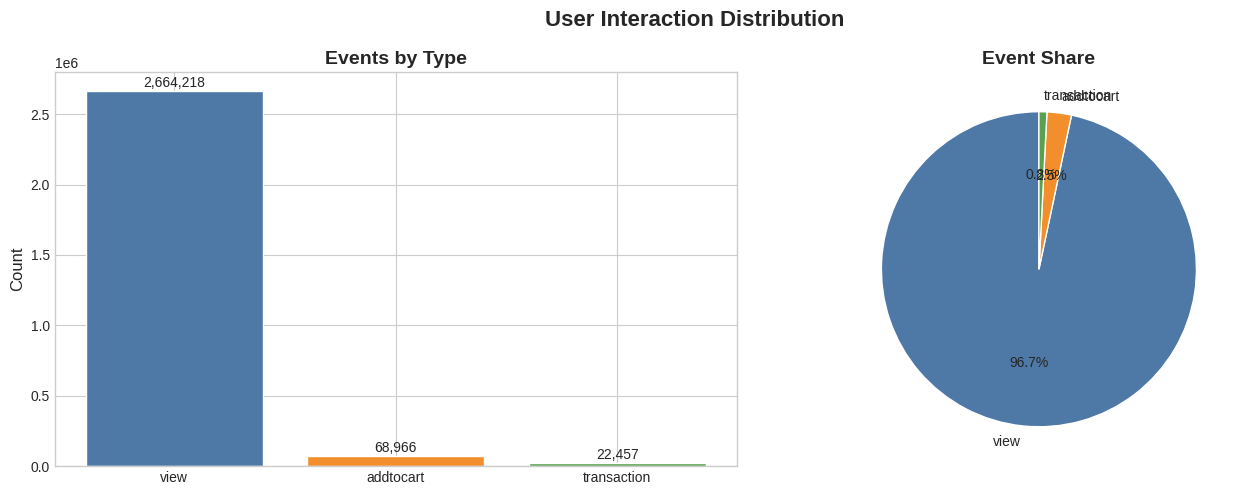


Conversion Rates:
  View -> Cart: 2.59%
  View -> Purchase: 0.84%
  Cart -> Purchase: 32.56%


In [24]:
# Event distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#4e79a7', '#f28e2b', '#59a14f']
event_counts = df['event'].value_counts()

bars = axes[0].bar(event_counts.index, event_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Events by Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

# Add value labels
for bar, val in zip(bars, event_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Event Share', fontsize=14, fontweight='bold')

plt.suptitle('User Interaction Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'event_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Calculate conversion rates
view_count = event_counts['view']
cart_count = event_counts['addtocart']
purchase_count = event_counts['transaction']

print("\nConversion Rates:")
print(f"  View -> Cart: {cart_count/view_count*100:.2f}%")
print(f"  View -> Purchase: {purchase_count/view_count*100:.2f}%")
print(f"  Cart -> Purchase: {purchase_count/cart_count*100:.2f}%")


In [35]:
# User conversion funnel

# Count unique users at each stage
viewers = df[df['event'] == 'view']['visitorid'].nunique()
carters = df[df['event'] == 'addtocart']['visitorid'].nunique()
buyers = df[df['event'] == 'transaction']['visitorid'].nunique()

# Create funnel chart
fig = go.Figure(go.Funnel(
    y=['Viewed Products', 'Added to Cart', 'Made Purchase'],
    x=[viewers, carters, buyers],
    textinfo='value+percent initial',
    marker=dict(color=['#4e79a7', '#f28e2b', '#59a14f'])
))

fig.update_layout(
    title='User Conversion Funnel (Unique Users)',
    height=400,
    showlegend=False
)

fig.show()

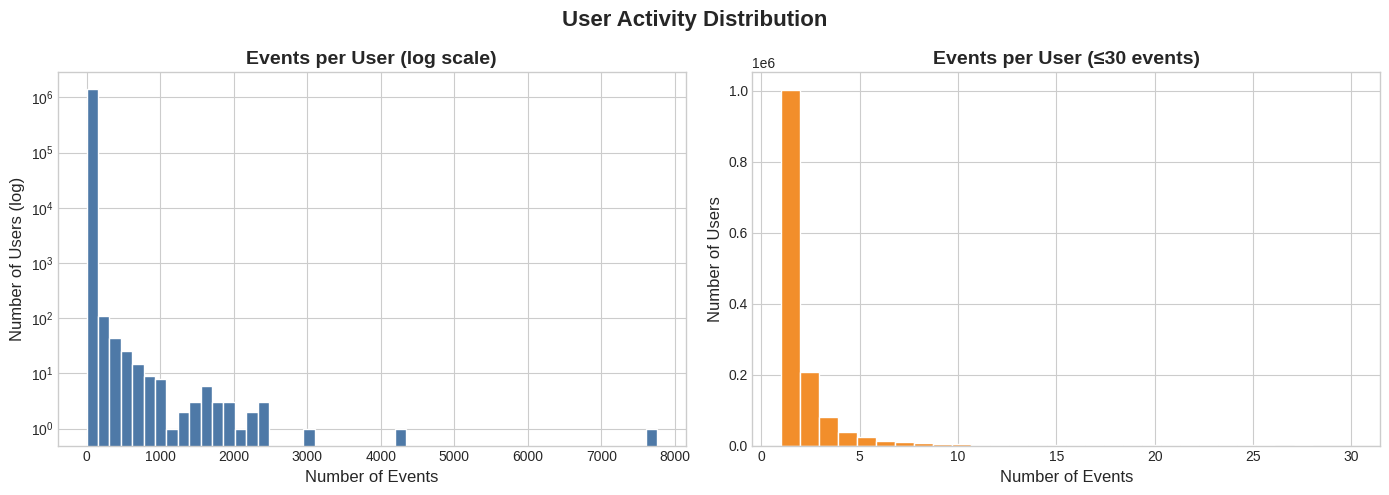


User activity stats:
  Average events per user: 1.96
  Median events per user: 1
  Most active user: 7,757 events
   Cold users (≤3 events): 1,287,208 (91.4%)


In [26]:

# User activity analysis

user_activity = df.groupby('visitorid').size().reset_index(name='event_count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution (log scale)
axes[0].hist(user_activity['event_count'], bins=50, color='#4e79a7',
             edgecolor='white', log=True)
axes[0].set_title('Events per User (log scale)', fontweight='bold')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Number of Users (log)')

# Zoom in on low-activity users
low_activity = user_activity[user_activity['event_count'] <= 30]
axes[1].hist(low_activity['event_count'], bins=30, color='#f28e2b', edgecolor='white')
axes[1].set_title('Events per User (≤30 events)', fontweight='bold')
axes[1].set_xlabel('Number of Events')
axes[1].set_ylabel('Number of Users')

plt.suptitle('User Activity Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'user_activity.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nUser activity stats:")
print(f"  Average events per user: {user_activity['event_count'].mean():.2f}")
print(f"  Median events per user: {user_activity['event_count'].median():.0f}")
print(f"  Most active user: {user_activity['event_count'].max():,} events")

# Cold users (few interactions)
cold_users = (user_activity['event_count'] <= 3).sum()
print(f"   Cold users (≤3 events): {cold_users:,} ({cold_users/len(user_activity)*100:.1f}%)")


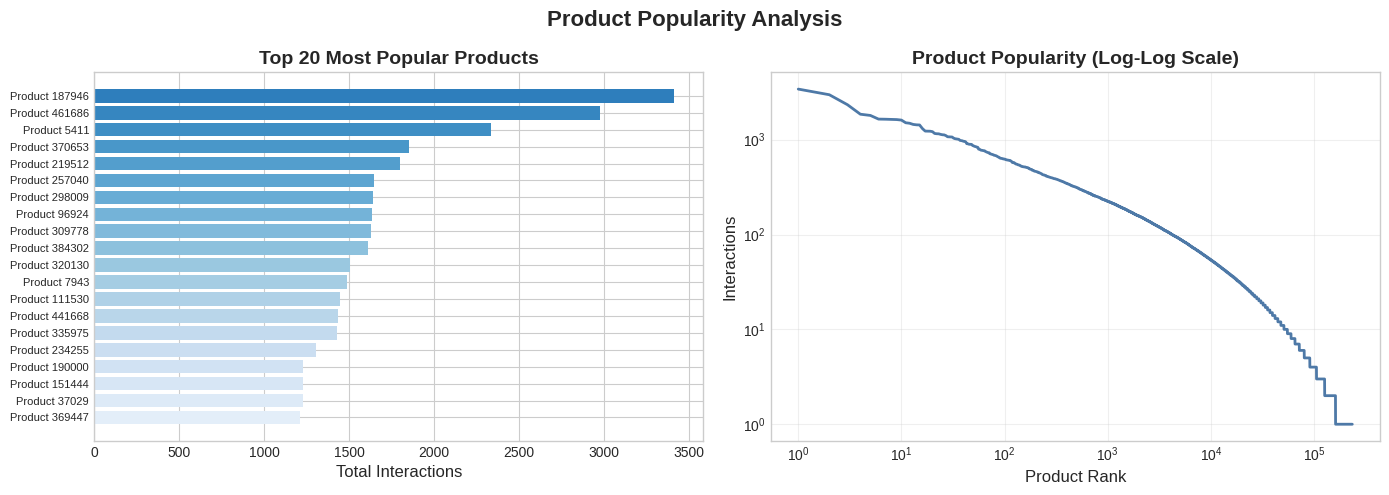


Popularity stats:
 Top 10% of products account for: 64.0% of all interactions
 Cold items (≤5 interactions): 154,767 (65.8%)


In [27]:
# Product popularity analysis

item_pop = df.groupby('itemid').size().reset_index(name='interactions')
item_pop = item_pop.sort_values('interactions', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 products
top20 = item_pop.head(20)
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, 20))
axes[0].barh(range(20), top20['interactions'], color=colors)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([f"Product {i}" for i in top20['itemid']], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Most Popular Products', fontweight='bold')
axes[0].set_xlabel('Total Interactions')

# Long-tail distribution
axes[1].loglog(range(1, len(item_pop)+1), item_pop['interactions'].values,
               color='#4e79a7', linewidth=2)
axes[1].set_title('Product Popularity (Log-Log Scale)', fontweight='bold')
axes[1].set_xlabel('Product Rank')
axes[1].set_ylabel('Interactions')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Product Popularity Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'product_popularity.png'), dpi=150, bbox_inches='tight')
plt.show()

# Calculate concentration
top10_percent = int(len(item_pop) * 0.1)
top10_share = item_pop.head(top10_percent)['interactions'].sum() / item_pop['interactions'].sum()

print(f"\nPopularity stats:")
print(f" Top 10% of products account for: {top10_share*100:.1f}% of all interactions")

cold_items = (item_pop['interactions'] <= 5).sum()
print(f" Cold items (≤5 interactions): {cold_items:,} ({cold_items/len(item_pop)*100:.1f}%)")


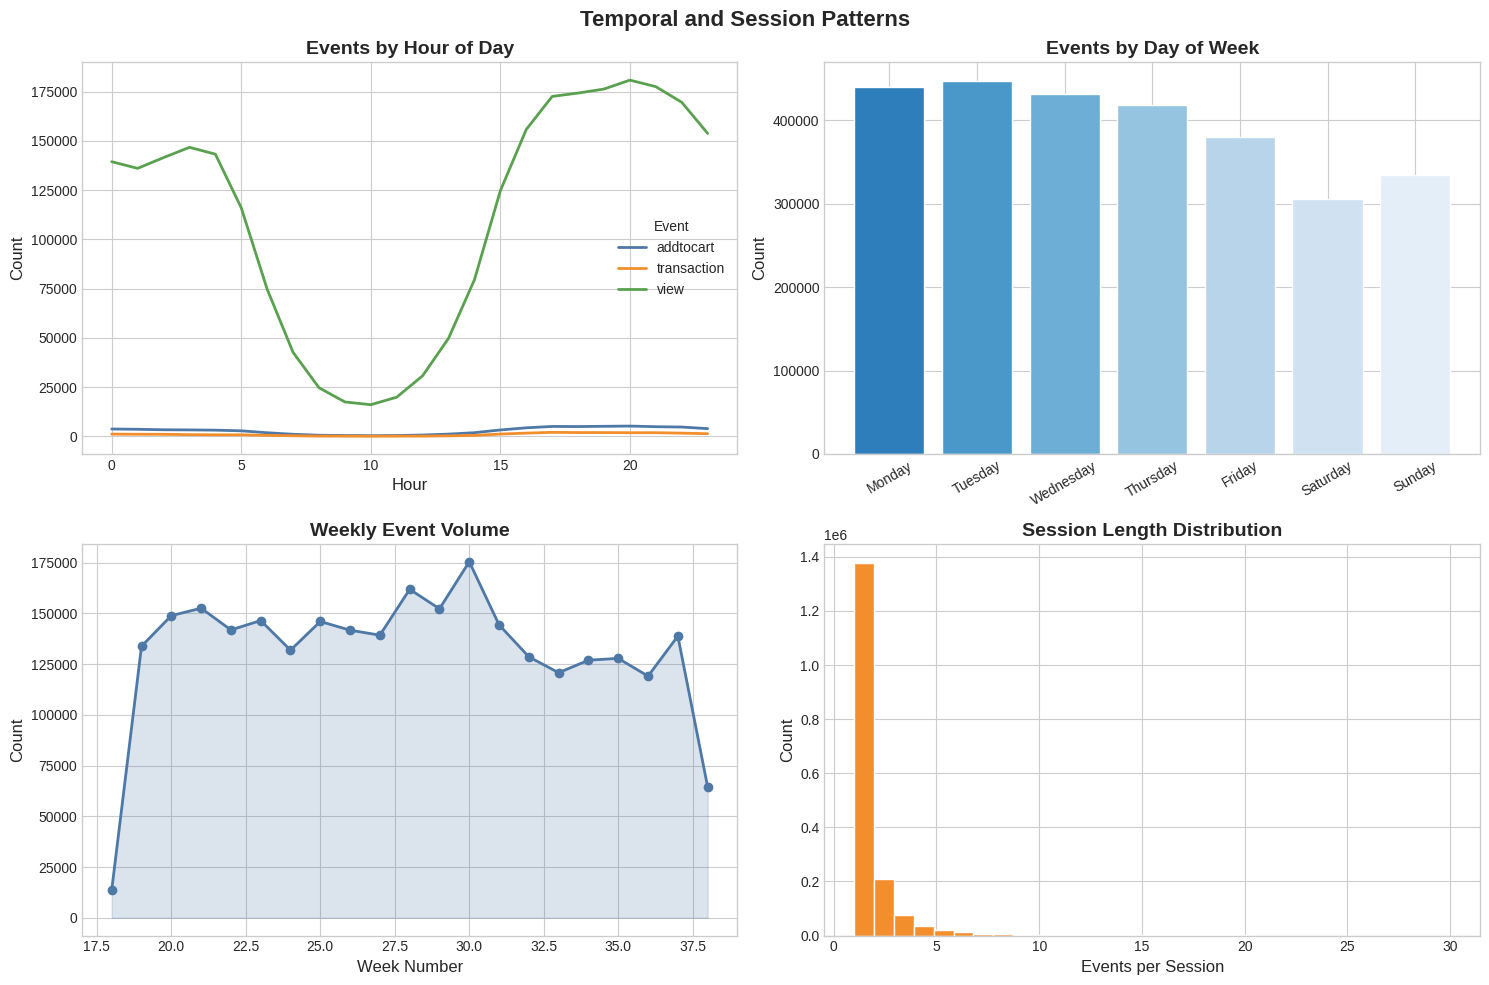

In [28]:
# Temporal patterns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Hourly pattern
hourly = df.groupby(['hour', 'event']).size().unstack(fill_value=0)
hourly.plot(ax=axes[0,0], color=['#4e79a7', '#f28e2b', '#59a14f'], linewidth=2)
axes[0,0].set_title('Events by Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(title='Event')

# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('dayofweek').size().reindex(day_order)
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, 7))
axes[0,1].bar(daily.index, daily.values, color=colors, edgecolor='white')
axes[0,1].set_title('Events by Day of Week', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_ylabel('Count')

# Weekly trend
weekly = df.groupby('week').size()
axes[1,0].plot(weekly.index, weekly.values, color='#4e79a7', marker='o', linewidth=2)
axes[1,0].fill_between(weekly.index, weekly.values, alpha=0.2, color='#4e79a7')
axes[1,0].set_title('Weekly Event Volume', fontweight='bold')
axes[1,0].set_xlabel('Week Number')
axes[1,0].set_ylabel('Count')

# Session length
session_len = df.groupby('session_id').size()
axes[1,1].hist(session_len[session_len <= 30], bins=30, color='#f28e2b', edgecolor='white')
axes[1,1].set_title('Session Length Distribution', fontweight='bold')
axes[1,1].set_xlabel('Events per Session')
axes[1,1].set_ylabel('Count')

plt.suptitle('Temporal and Session Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'temporal_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1400x600 with 0 Axes>

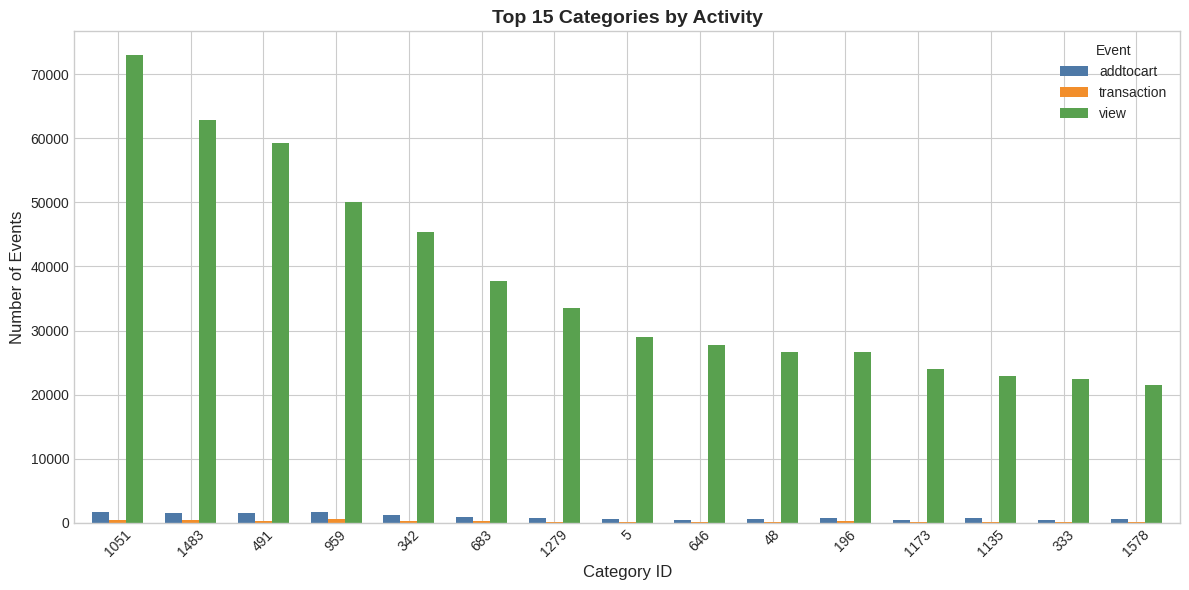


Category tree stats:
  Root categories: 25
  Total categories: 1669


In [29]:

# Category analysis

# Filter events with category info
df_cat = df[df['categoryid'] != -1]

if len(df_cat) > 0:
    # Top categories by views
    cat_events = df_cat.groupby(['categoryid', 'event']).size().unstack(fill_value=0)
    cat_events = cat_events.sort_values('view', ascending=False).head(15)

    plt.figure(figsize=(14, 6))
    cat_events.plot(kind='bar', color=['#4e79a7', '#f28e2b', '#59a14f'], width=0.7)
    plt.title('Top 15 Categories by Activity', fontweight='bold', fontsize=14)
    plt.xlabel('Category ID')
    plt.ylabel('Number of Events')
    plt.xticks(rotation=45)
    plt.legend(title='Event')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'category_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Category tree info
    root_cats = category_tree[category_tree['parentid'].isna()]['categoryid'].nunique()
    print(f"\nCategory tree stats:")
    print(f"  Root categories: {root_cats}")
    print(f"  Total categories: {len(category_tree)}")
else:
    print("No category data available - check item_properties files")


In [30]:
# Cold-start analysis

user_counts = df.groupby('visitorid').size()
item_counts = df.groupby('itemid').size()

print("\nUsers:")
user_thresholds = [1, 2, 3, 5, 10]
for thresh in user_thresholds:
    cold = (user_counts <= thresh).sum()
    pct = cold/len(user_counts)*100
    print(f"   ≤{thresh:2} events: {cold:6,} users ({pct:.1f}%)")

print("\nItems:")
item_thresholds = [1, 2, 5, 10, 20]
for thresh in item_thresholds:
    cold = (item_counts <= thresh).sum()
    pct = cold/len(item_counts)*100
    print(f"   ≤{thresh:2} events: {cold:6,} items ({pct:.1f}%)")

print(f"\nOverall sparsity: {sparsity*100:.4f}%")
print("\nThis high sparsity means we need algorithms that handle cold-start well")
print(" (like session-based recommendations or matrix factorization)")



Users:
   ≤ 1 events: 1,001,591 users (71.2%)
   ≤ 2 events: 1,207,597 users (85.8%)
   ≤ 3 events: 1,287,208 users (91.4%)
   ≤ 5 events: 1,348,953 users (95.8%)
   ≤10 events: 1,388,013 users (98.6%)

Items:
   ≤ 1 events: 73,616 items (31.3%)
   ≤ 2 events: 108,446 items (46.1%)
   ≤ 5 events: 154,767 items (65.8%)
   ≤10 events: 184,005 items (78.3%)
   ≤20 events: 205,922 items (87.6%)

Overall sparsity: 99.9994%

This high sparsity means we need algorithms that handle cold-start well
 (like session-based recommendations or matrix factorization)


In [31]:

#  EDA Summary
print("EDA SUMMARY\n")

summary_stats = {
    "Total Events": f"{len(df):,}",
    "Unique Users": f"{df['visitorid'].nunique():,}",
    "Unique Products": f"{df['itemid'].nunique():,}",
    "Total Sessions": f"{df['session_id'].nunique():,}",
    "Views": f"{(df['event']=='view').sum():,}",
    "Cart Adds": f"{(df['event']=='addtocart').sum():,}",
    "Purchases": f"{(df['event']=='transaction').sum():,}",
    "View→Purchase Rate": f"{(df['event']=='transaction').sum()/(df['event']=='view').sum()*100:.3f}%",
    "Data Sparsity": f"{sparsity*100:.2f}%",
    "Avg Events/User": f"{len(df)/df['visitorid'].nunique():.2f}",
    "Avg Events/Session": f"{len(df)/df['session_id'].nunique():.2f}",
    "Time Span": f"{(df['datetime'].max() - df['datetime'].min()).days} days"
}

for key, value in summary_stats.items():
    print(f"{key:<25}: {value}")


EDA SUMMARY

Total Events             : 2,755,641
Unique Users             : 1,407,580
Unique Products          : 235,061
Total Sessions           : 1,761,675
Views                    : 2,664,218
Cart Adds                : 68,966
Purchases                : 22,457
View→Purchase Rate       : 0.843%
Data Sparsity            : 100.00%
Avg Events/User          : 1.96
Avg Events/Session       : 1.56
Time Span                : 137 days


## Save Processed Data

In [32]:
# Save all artifacts

# Processed events (Parquet format - smaller & faster)
df.to_parquet(os.path.join(ARTIFACT_PATH, 'processed_events.parquet'), index=False)
print("Saved: processed_events.parquet")

# User-item interactions
user_item.to_csv(os.path.join(ARTIFACT_PATH, 'user_item_matrix.csv'), index=False)
print("Saved: user_item_matrix.csv")

# Item metadata
item_meta.to_csv(os.path.join(ARTIFACT_PATH, 'item_metadata.csv'), index=False)
print("Saved: item_metadata.csv")

# Co-occurrence matrix
co_occur_df.to_csv(os.path.join(ARTIFACT_PATH, 'co_occurrence.csv'), index=False)
print("Saved: co_occurrence.csv")

# Session transitions (as pickle)
with open(os.path.join(ARTIFACT_PATH, 'item_transitions.pkl'), 'wb') as f:
    pickle.dump(item_transitions, f)
print("Saved: item_transitions.pkl")

# Item frequencies
with open(os.path.join(ARTIFACT_PATH, 'item_frequencies.pkl'), 'wb') as f:
    pickle.dump(dict(item_freq), f)
print("Saved: item_frequencies.pkl")

# Summary statistics
with open(os.path.join(PROJECT_PATH, 'output', 'evaluation_results', 'data_summary.txt'), 'w') as f:
    for key, value in summary_stats.items():
        f.write(f"{key}: {value}\n")
print("Saved: data_summary.txt")

Saved: processed_events.parquet
Saved: user_item_matrix.csv
Saved: item_metadata.csv
Saved: co_occurrence.csv
Saved: item_transitions.pkl
Saved: item_frequencies.pkl
Saved: data_summary.txt


In [33]:
# Quick verification
print("\nVerifying saved files...")
saved_files = os.listdir(ARTIFACT_PATH)
print(f"\nFiles in {ARTIFACT_PATH}:")
for file in sorted(saved_files):
    size = os.path.getsize(os.path.join(ARTIFACT_PATH, file))
    if size < 1024*1024:
        print(f"   {file:<30} {size/1024:.1f} KB")
    else:
        print(f"   {file:<30} {size/(1024*1024):.1f} MB")



Verifying saved files...

Files in ./data/processed:
   co_occurrence.csv              8.1 MB
   item_frequencies.pkl           826.5 KB
   item_metadata.csv              5.2 MB
   item_transitions.pkl           5.1 MB
   processed_events.parquet       87.1 MB
   user_item_matrix.csv           32.7 MB


In [34]:
# Ready for next notebook
print(" NOTEBOOK 1 COMPLETE!")
print("\nData preparation finished successfully")
print("EDA insights documented")
print("All artifacts saved")
print("\nNext steps:")
print("   1. Review the EDA findings above")
print("   2. Open Notebook 2: Model Building & Evaluation")
print("   3. Load the saved artifacts and start building recommenders")

 NOTEBOOK 1 COMPLETE!

Data preparation finished successfully
EDA insights documented
All artifacts saved

Next steps:
   1. Review the EDA findings above
   2. Open Notebook 2: Model Building & Evaluation
   3. Load the saved artifacts and start building recommenders
